# **Comparative Analysis of Tripartite Networks**

# Import Libraries and Configurations

In [1]:
import ast
import os
import sys
from itertools import combinations, permutations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib_venn import venn2, venn3
from venn import venn

# Add project root to Python's path
sys.path.append(os.path.abspath(os.path.join('..')))

from config import (
    DATA_SUBDIRS,
    NETWORK_DATA_DIRS,
)

# Remove the HER2-enriched group from the analysis
GROUPS = DATA_SUBDIRS.copy()
GROUPS.remove('her2-enriched')

# Metrics calculated in the individual analysis
METRICS = [
    # 'degree', 
    'betweenness_centrality', 
    'closeness_centrality', 
    'degree_centrality', 
    'redundancy_coefficient', 
    'pathway_reach',
    'functional_impact',
]

# Thresholds for node classification
LOWER_NODE_RANKING_THRESHOLD = 0.25
UPPER_NODE_RANKING_THRESHOLD = 0.50
JACCARD_NODE_RANKING_THRESHOLD = 0.25

# Functions

## Venn Diagram Plot

In [2]:
def plot_venn_diagram(df_nodes, element_name):
    # Create a dictionary to store the sets by group
    sets = dict()

    # Select the microRNA nodes and convert the `paths` column
    df_mir_nodes = \
        df_nodes.query('type == "MicroRNA"').copy()
    df_mir_nodes['paths'] = \
        df_mir_nodes['paths'].apply(ast.literal_eval)

    # Iterate over the groups
    groups = df_mir_nodes['group'].unique()
    for group in groups:
        # Select the nodes in the group
        df_group_nodes = df_mir_nodes.query('group == @group')

        # Create lists with microRNAs and other path nodes
        mirs = df_group_nodes['id'].to_list()
        paths = df_group_nodes['paths'].to_list()

        # Create a list to store the elements of the group
        elements = list()

        # Iterate over microRNAs
        for row, mir in enumerate(mirs):
            # Iterate over microRNA paths
            for path in paths[row]:
                # Assemble the string
                if element_name == 'paths':
                    element = f'{mir}_{path[0]}_{path[1]}'
                elif element_name == 'pairs':
                    element = f'{mir}_{path[1]}'
                
                # Add the element string in the group list
                elements.append(element)

        # Add the group set in the dictionary
        sets[group] = set(elements)

    # Create the diagram according to the number of sets
    subsets = list(sets.values())
    set_labels = list(sets.keys())
    if len(groups) == 2:
        venn2(subsets=subsets, set_labels=set_labels)
    elif len(groups) == 3:
        venn3(subsets=subsets, set_labels=set_labels)
    else:
        venn(sets)

    # Plot the Venn diagram
    title = f'Tripartite Networks - {element_name.capitalize()}'
    plt.title(title)
    plt.show()

    return sets

## Operations Between Sets

### Print the Intersection Elements

In [3]:
def print_intersection_elements(sets):
    # Create a list of all groups
    groups = sets.keys()

    print(f'===== Tripartite Networks =====')

    # Print the intersections between three sets, if necessary
    if len(groups) == 3:
        print('\n##### 3-Set Intersections #####')
        for s1, s2, s3 in combinations(groups, 3):
            # Select each of the sets
            set1 = set(sets[s1])
            set2 = set(sets[s2])
            set3 = set(sets[s3])

            # Compute the intersection
            inter = set1 & set2 & set3
            print(f'\n> {s1} ∩ {s2} ∩ {s3} = {len(inter)}')

            # Print the elements at the intersection
            for edge in sorted(inter):
                print(edge.split('_'))
    
    # Print the intersections between two sets
    print('\n##### 2-Set Intersections #####')
    for s1, s2 in combinations(groups, 2):
        # Select each of the sets
        set1 = set(sets[s1])
        set2 = set(sets[s2])

        # Compute the intersection
        inter = set1 & set2
        print(f'\n> {s1} ∩ {s2} = {len(inter)}')

        # Print the elements at the intersection
        for edge in sorted(inter):
            print(edge.split('_'))

### Print the Difference Elements

In [4]:
def print_different_elements(sets):
    # Create a list of all groups
    groups = sets.keys()

    print(f'===== Tripartite Networks =====')

    # Print the differences between three sets, if necessary
    if len(groups) == 3:
        print('\n##### 3-Set Differences #####')
        for s1 in groups:
            remaining = [s for s in groups if s != s1]
            for s2, s3 in combinations(remaining, 2):
                # Select each of the sets
                set1 = set(sets[s1])
                set2 = set(sets[s2])
                set3 = set(sets[s3])

                # Compute the difference
                diff = set1 - (set2 | set3)
                print(f'\n> {s1} - ({s2} ∪ {s3}) = {len(diff)}')

                # Print the elements of the difference
                for edge in sorted(diff):
                    print(edge.split('_'))

    # Print the differences between the sets
    print('\n##### 2-Set Differences #####')
    for s1, s2 in permutations(groups, 2):
        # Select each of the sets
        set1 = set(sets[s1])
        set2 = set(sets[s2])

        # Compute the difference
        diff = set1 - set2
        print(f'\n> {s1} - {s2} = {len(diff)}')

        # Print the elements of the difference
        for edge in sorted(diff):
            print(edge.split('_'))

## Classification of Node Specificity

### Rank Nodes by Metric Values

In [5]:
def rank_nodes_by_metric_values(
    df_nodes, metric, ascending_order=False
):
    # Create a dictionary to store ranked lists of nodes
    ranked_nodes = dict()

    # Iterate over the groups
    groups = df_nodes['group'].unique()
    for group in groups:
        # Sort the nodes according to their metric values
        df_metric_ranked = df_nodes \
            .query('(group == @group) and (type == "MicroRNA")') \
            .dropna(subset=metric) \
            .sort_values(by=metric, ascending=ascending_order)
        
        # Store the ranked list of nodes on the dictionary
        ranked_nodes[group] = df_metric_ranked['id'].to_list()
    
    return ranked_nodes

### Classify the Specificity of the Nodes

In [6]:
def classify_node_specifity(ranked_nodes):
    # Create dictionaries to store specific and non-specific nodes
    specific = dict()
    non_specific = dict()

    # Iterate over the groups
    groups = ranked_nodes.keys()
    for group1 in groups:
        # Select the ranked nodes related to the group
        group1_nodes = ranked_nodes[group1]

        # Iterate over nodes within the lower threshold
        lower_threshold = int(
            LOWER_NODE_RANKING_THRESHOLD 
            * len(group1_nodes)
        )
        for node in group1_nodes[:lower_threshold]:
            # Create a list to store the groups where the node is important
            node_groups = [group1]

            # Iterate over the other groups
            for group2 in groups:
                if group2 == group1:
                    continue

                # Select the ranked nodes related to the other group
                group2_nodes = ranked_nodes[group2]

                # Check if the node is specific to the first group
                upper_threshold = int(
                    UPPER_NODE_RANKING_THRESHOLD 
                    * len(group2_nodes)
                )
                if node in group2_nodes[:upper_threshold]:
                    node_groups.append(group2)

            # Store the node as specific or non-specific
            if len(node_groups) == 1:
                specific[node] = sorted(node_groups)
            else:
                non_specific[node] = sorted(node_groups)
        
        # Create a dictionary to store nodes by specificity
        node_specificity = dict()
        node_specificity['specific'] = specific
        node_specificity['non_specific'] = non_specific

    return node_specificity

### Classify Non-specific Nodes

In [7]:
def classify_non_specific_nodes(df_edges, node_specificity):
    # Create dictionaries to store common and differential nodes
    common = dict()
    differential = dict()
    
    # Check if the nodes are in the `source` or `target` column
    non_specific = node_specificity['non_specific']
    sample_node = list(non_specific.keys())[0]
    edge_list = df_edges \
        .query('source == @sample_node') \
        ['target'].to_list()

    if len(edge_list) > 0:
        col1 = 'source'
        col2 = 'target'
    else:
        col1 = 'target'
        col2 = 'source'

    # Iterate over non-specific nodes
    for node in non_specific.keys():
        # Groups where the node is "important"
        groups = non_specific[node]

        # Select the edges that enclose the node
        df_node_edges = df_edges[df_edges[col1] == node]

        # Create a list to store the similarity between groups
        similarity = list()
        is_differential = True

        # Iterate over the possible group combinations
        for g1, g2 in combinations(groups, 2):
            # Define the neighborhood in each group
            g1_neighbors = set(
                df_node_edges.query('group == @g1')[col2].to_list()
            )
            g2_neighbors = set(
                df_node_edges.query('group == @g2')[col2].to_list()
            )

            # Calculate the Jaccard similarity between neighborhoods
            intersection = g1_neighbors & g2_neighbors
            union = g1_neighbors | g2_neighbors
            jaccard_index = len(intersection) / len(union)

            # Check if the combination characterizes a common node
            if jaccard_index >= JACCARD_NODE_RANKING_THRESHOLD:
                is_differential = False

            # Store the similarity between the two groups
            similarity.append((g1, g2, round(jaccard_index, 3)))

        # Store the node as differential or common
        if is_differential:
            differential[node] = similarity
        else:
            common[node] = similarity

    # Store the two new node specificity classifications
    node_specificity['common'] = common
    node_specificity['differential'] = differential

    return node_specificity

### Print Node Classification

In [8]:
def print_node_classification(analyzed_networks):
    print(f'===== Tripartite Networks - MicroRNA Nodes =====')

    # Iterate over topological metrics
    for metric in METRICS[-2:]:
        subtitle = (metric.replace('_', ' ')).title()
        # Iterate over the different rankings
        for ascending_order in [False, True]:
            ranking = 'Ascending' if ascending_order else 'Descending'
            print(f'\n##### {subtitle} - {ranking} Ranking #####')
            
            # Rank the nodes according to the metric values
            ranked_nodes = rank_nodes_by_metric_values(
                analyzed_networks['nodes'], metric, ascending_order
            )

            # Classify the nodes as specific or non-specific
            node_specificity = classify_node_specifity(ranked_nodes)

            # Classify the non-specific nodes as common or differential
            if node_specificity['non_specific']:
                node_specificity = classify_non_specific_nodes(
                    analyzed_networks['edges'], node_specificity
                )

            # Iterate over the classifications
            for classification in node_specificity.keys():
                # Print the nodes and their related groups
                elements = node_specificity[classification]
                print(f'\n> {classification} = {len(elements)}')

                for node in sorted(elements.keys()):
                    print(f'- {node}: {elements[node]}')

## Pairwise Metric Relationships Plot

In [9]:
def annotate_correlation(x, y, **kws):
    # Get the axes object
    ax = plt.gca()

    # Avoid re-annotating the same object
    if hasattr(ax, '_corr_annotated'):
        return
    ax._corr_annotated = True

    # Compute the correlation between the axis
    corr = pd.Series(x).corr(pd.Series(y), method='spearman')

    # Annotate the correlation value in the plot
    ax.annotate(
        f'ρ = {corr:.2f}' if pd.notna(corr) else 'ρ = NA',
        xy=(0.7, 0.95),
        xycoords='axes fraction',
        fontsize=10,
        ha='left',
        va='center',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.3),
    )

In [10]:
def plot_pairwise_grid(df_nodes):
    # Select the data of interest
    df_partition_nodes = \
        df_nodes.query('type == "MicroRNA"')

    # Create the pair grid for the metric combinations
    g = sns.PairGrid(
        data=df_partition_nodes,
        hue='group',
        vars=METRICS,
        diag_sharey=False,
    )

    # Configure the histograms to appear diagonally
    g.map_diag(
        func=sns.histplot, 
        multiple='stack', 
        element='step',
        alpha=0.8,
    )

    # Configure the scatter plots to appear outside the diagonal
    g.map_offdiag(
        func=sns.scatterplot, 
        alpha=0.8,
    )

    # Annotate the correlation value in each scatter plot
    g.map_offdiag(annotate_correlation)

    # Plot the pair grid
    title = (
        'Relationships Between Pairs of Metrics for MicroRNA ' 
        + 'Nodes in Bipartite and Tripartite Networks' 
    )
    plt.suptitle(t=title, y=1.02)
    g.add_legend()
    plt.show()

# Load the Data

In [11]:
# Create a dictionary to store DataFrames related to network analysis
analyzed_networks = dict()
analyzed_networks['edges'] = pd.DataFrame()
analyzed_networks['nodes'] = pd.DataFrame()

# Iterate over the groups
for group in GROUPS:    
    group_dir = (group.lower()).replace(' ', '-')
    dir_path = NETWORK_DATA_DIRS['processed'][group_dir]

    edges_file = 'tripartite-network-edges.csv'
    df_edges = pd.read_csv(os.path.join(dir_path, edges_file))
    df_edges['group'] = group

    nodes_file = 'tripartite-network-nodes-with-metrics.csv'
    df_nodes = pd.read_csv(os.path.join(dir_path, nodes_file))
    df_nodes['group'] = group

    # Concatenate the edges and nodes of the group to the others
    analyzed_networks['edges'] = pd.concat(
        objs=[analyzed_networks['edges'], df_edges], 
        ignore_index=True
    )
    analyzed_networks['nodes'] = pd.concat(
        objs=[analyzed_networks['nodes'], df_nodes], 
        ignore_index=True
    )

# Only Cancer

## Data Preparation

In [12]:
# Create a dictionary to store data only about cancer
cancer_networks = dict()

# Iterate over the network elements
for element in ['edges', 'nodes']:
    cancer_networks[element] = \
        analyzed_networks[element] \
        .query('group != "normal"') \
        .reset_index(drop=True)

## MicroRNA-Gene-Pathway Path Sets

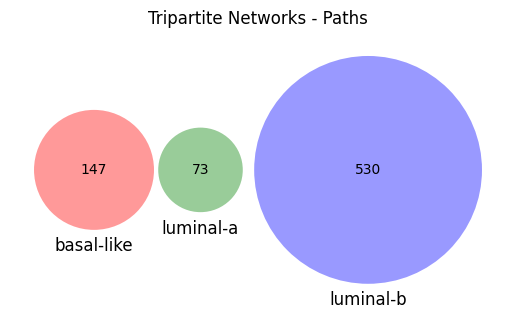

In [13]:
# Plot the Venn diagram of microRNA-gene-pathway paths
path_sets = plot_venn_diagram(
    df_nodes=cancer_networks['nodes'], 
    element_name='paths'
)

### Intersections

In [14]:
# Print the microRNA-gene-pathway paths 
# resulting from the intersection between groups
print_intersection_elements(path_sets)

===== Tripartite Networks =====

##### 3-Set Intersections #####

> basal-like ∩ luminal-a ∩ luminal-b = 0

##### 2-Set Intersections #####

> basal-like ∩ luminal-a = 0

> basal-like ∩ luminal-b = 0

> luminal-a ∩ luminal-b = 0


### Differences

In [15]:
# Print the microRNA-gene-pathway paths 
# resulting from the difference between groups
print_different_elements(path_sets)

===== Tripartite Networks =====

##### 3-Set Differences #####

> basal-like - (luminal-a ∪ luminal-b) = 147
['hsa-let-7c-5p', 'IGF1R', 'KEGG:05202']
['hsa-let-7e-5p', 'CD200R1', 'KEGG:01521']
['hsa-let-7e-5p', 'CD200R1', 'KEGG:01522']
['hsa-let-7e-5p', 'CD200R1', 'KEGG:04010']
['hsa-let-7e-5p', 'CD200R1', 'KEGG:04014']
['hsa-let-7e-5p', 'CD200R1', 'KEGG:04068']
['hsa-let-7e-5p', 'CD200R1', 'KEGG:04115']
['hsa-let-7e-5p', 'CD200R1', 'KEGG:04211']
['hsa-let-7e-5p', 'CD200R1', 'KEGG:05200']
['hsa-let-7e-5p', 'CD200R1', 'KEGG:05202']
['hsa-let-7e-5p', 'CD200R1', 'KEGG:05205']
['hsa-let-7e-5p', 'CD200R1', 'KEGG:05214']
['hsa-miR-106a-5p', 'AFF1', 'KEGG:01521']
['hsa-miR-106a-5p', 'AFF1', 'KEGG:04010']
['hsa-miR-106a-5p', 'AFF1', 'KEGG:04014']
['hsa-miR-106a-5p', 'AFF1', 'KEGG:04020']
['hsa-miR-106a-5p', 'AFF1', 'KEGG:05200']
['hsa-miR-106a-5p', 'AFF1', 'KEGG:05214']
['hsa-miR-106a-5p', 'RASGRF2', 'KEGG:04010']
['hsa-miR-106a-5p', 'RASGRF2', 'KEGG:04014']
['hsa-miR-106a-5p', 'SESN3', 'KEGG:

## MicroRNA-Pathway Pair Sets

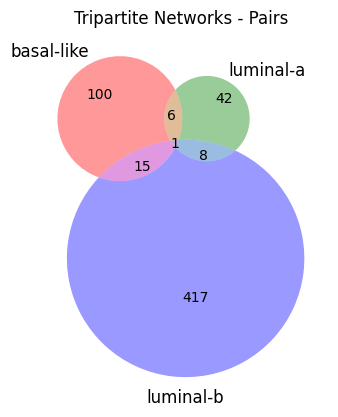

In [16]:
# Plot the Venn diagram of microRNA-pathway pairs
pair_sets = plot_venn_diagram(
    df_nodes=cancer_networks['nodes'], 
    element_name='pairs'
    )

### Intersections

In [17]:
# Print the microRNA-pathway pairs 
# resulting from the intersection between groups
print_intersection_elements(pair_sets)

===== Tripartite Networks =====

##### 3-Set Intersections #####

> basal-like ∩ luminal-a ∩ luminal-b = 1
['hsa-miR-29b-3p', 'KEGG:05202']

##### 2-Set Intersections #####

> basal-like ∩ luminal-a = 7
['hsa-miR-106b-5p', 'KEGG:05202']
['hsa-miR-200a-3p', 'KEGG:05202']
['hsa-miR-200b-3p', 'KEGG:05202']
['hsa-miR-200c-3p', 'KEGG:05202']
['hsa-miR-29b-3p', 'KEGG:05202']
['hsa-miR-33b-5p', 'KEGG:05202']
['hsa-miR-96-5p', 'KEGG:05202']

> basal-like ∩ luminal-b = 16
['hsa-miR-106a-5p', 'KEGG:05200']
['hsa-miR-106b-5p', 'KEGG:01521']
['hsa-miR-106b-5p', 'KEGG:04010']
['hsa-miR-106b-5p', 'KEGG:04014']
['hsa-miR-18a-5p', 'KEGG:04010']
['hsa-miR-200c-3p', 'KEGG:05214']
['hsa-miR-221-3p', 'KEGG:05205']
['hsa-miR-25-3p', 'KEGG:01521']
['hsa-miR-27a-3p', 'KEGG:05202']
['hsa-miR-29b-3p', 'KEGG:05202']
['hsa-miR-30b-5p', 'KEGG:05200']
['hsa-miR-30b-5p', 'KEGG:05202']
['hsa-miR-96-5p', 'KEGG:04010']
['hsa-miR-96-5p', 'KEGG:04014']
['hsa-miR-96-5p', 'KEGG:05200']
['hsa-miR-96-5p', 'KEGG:05205']

> l

### Differences

In [18]:
# Print the microRNA-pathway pairs 
# resulting from the difference between groups
print_different_elements(pair_sets)

===== Tripartite Networks =====

##### 3-Set Differences #####

> basal-like - (luminal-a ∪ luminal-b) = 100
['hsa-let-7c-5p', 'KEGG:05202']
['hsa-let-7e-5p', 'KEGG:01521']
['hsa-let-7e-5p', 'KEGG:01522']
['hsa-let-7e-5p', 'KEGG:04010']
['hsa-let-7e-5p', 'KEGG:04014']
['hsa-let-7e-5p', 'KEGG:04068']
['hsa-let-7e-5p', 'KEGG:04115']
['hsa-let-7e-5p', 'KEGG:04211']
['hsa-let-7e-5p', 'KEGG:05200']
['hsa-let-7e-5p', 'KEGG:05202']
['hsa-let-7e-5p', 'KEGG:05205']
['hsa-let-7e-5p', 'KEGG:05214']
['hsa-miR-106a-5p', 'KEGG:01521']
['hsa-miR-106a-5p', 'KEGG:04010']
['hsa-miR-106a-5p', 'KEGG:04014']
['hsa-miR-106a-5p', 'KEGG:04020']
['hsa-miR-106a-5p', 'KEGG:04115']
['hsa-miR-106a-5p', 'KEGG:05214']
['hsa-miR-106b-5p', 'KEGG:01522']
['hsa-miR-106b-5p', 'KEGG:04020']
['hsa-miR-106b-5p', 'KEGG:04068']
['hsa-miR-106b-5p', 'KEGG:04115']
['hsa-miR-106b-5p', 'KEGG:04659']
['hsa-miR-106b-5p', 'KEGG:05200']
['hsa-miR-106b-5p', 'KEGG:05205']
['hsa-miR-128-3p', 'KEGG:05202']
['hsa-miR-130b-3p', 'KEGG:05202'

## Node Classification

In [19]:
# Print the classification of the nodes according to the metric values
print_node_classification(cancer_networks)

===== Tripartite Networks - MicroRNA Nodes =====

##### Pathway Reach - Descending Ranking #####

> specific = 23
- hsa-let-7e-5p: ['basal-like']
- hsa-miR-125b-5p: ['luminal-b']
- hsa-miR-130b-3p: ['luminal-b']
- hsa-miR-15b-5p: ['luminal-b']
- hsa-miR-181b-5p: ['luminal-b']
- hsa-miR-185-5p: ['luminal-b']
- hsa-miR-186-5p: ['luminal-b']
- hsa-miR-192-5p: ['luminal-a']
- hsa-miR-196a-5p: ['basal-like']
- hsa-miR-205-5p: ['luminal-b']
- hsa-miR-222-3p: ['basal-like']
- hsa-miR-26a-5p: ['luminal-b']
- hsa-miR-27a-3p: ['luminal-b']
- hsa-miR-27b-3p: ['luminal-b']
- hsa-miR-330-3p: ['luminal-b']
- hsa-miR-335-5p: ['basal-like']
- hsa-miR-34a-5p: ['luminal-b']
- hsa-miR-363-3p: ['luminal-a']
- hsa-miR-378a-3p: ['luminal-b']
- hsa-miR-378c: ['luminal-b']
- hsa-miR-429: ['luminal-a']
- hsa-miR-92a-3p: ['basal-like']
- hsa-miR-93-5p: ['basal-like']

> non_specific = 18
- hsa-miR-106a-5p: ['basal-like', 'luminal-b']
- hsa-miR-106b-5p: ['basal-like', 'luminal-a', 'luminal-b']
- hsa-miR-148a-3p:

## Pairwise Metric Relationships

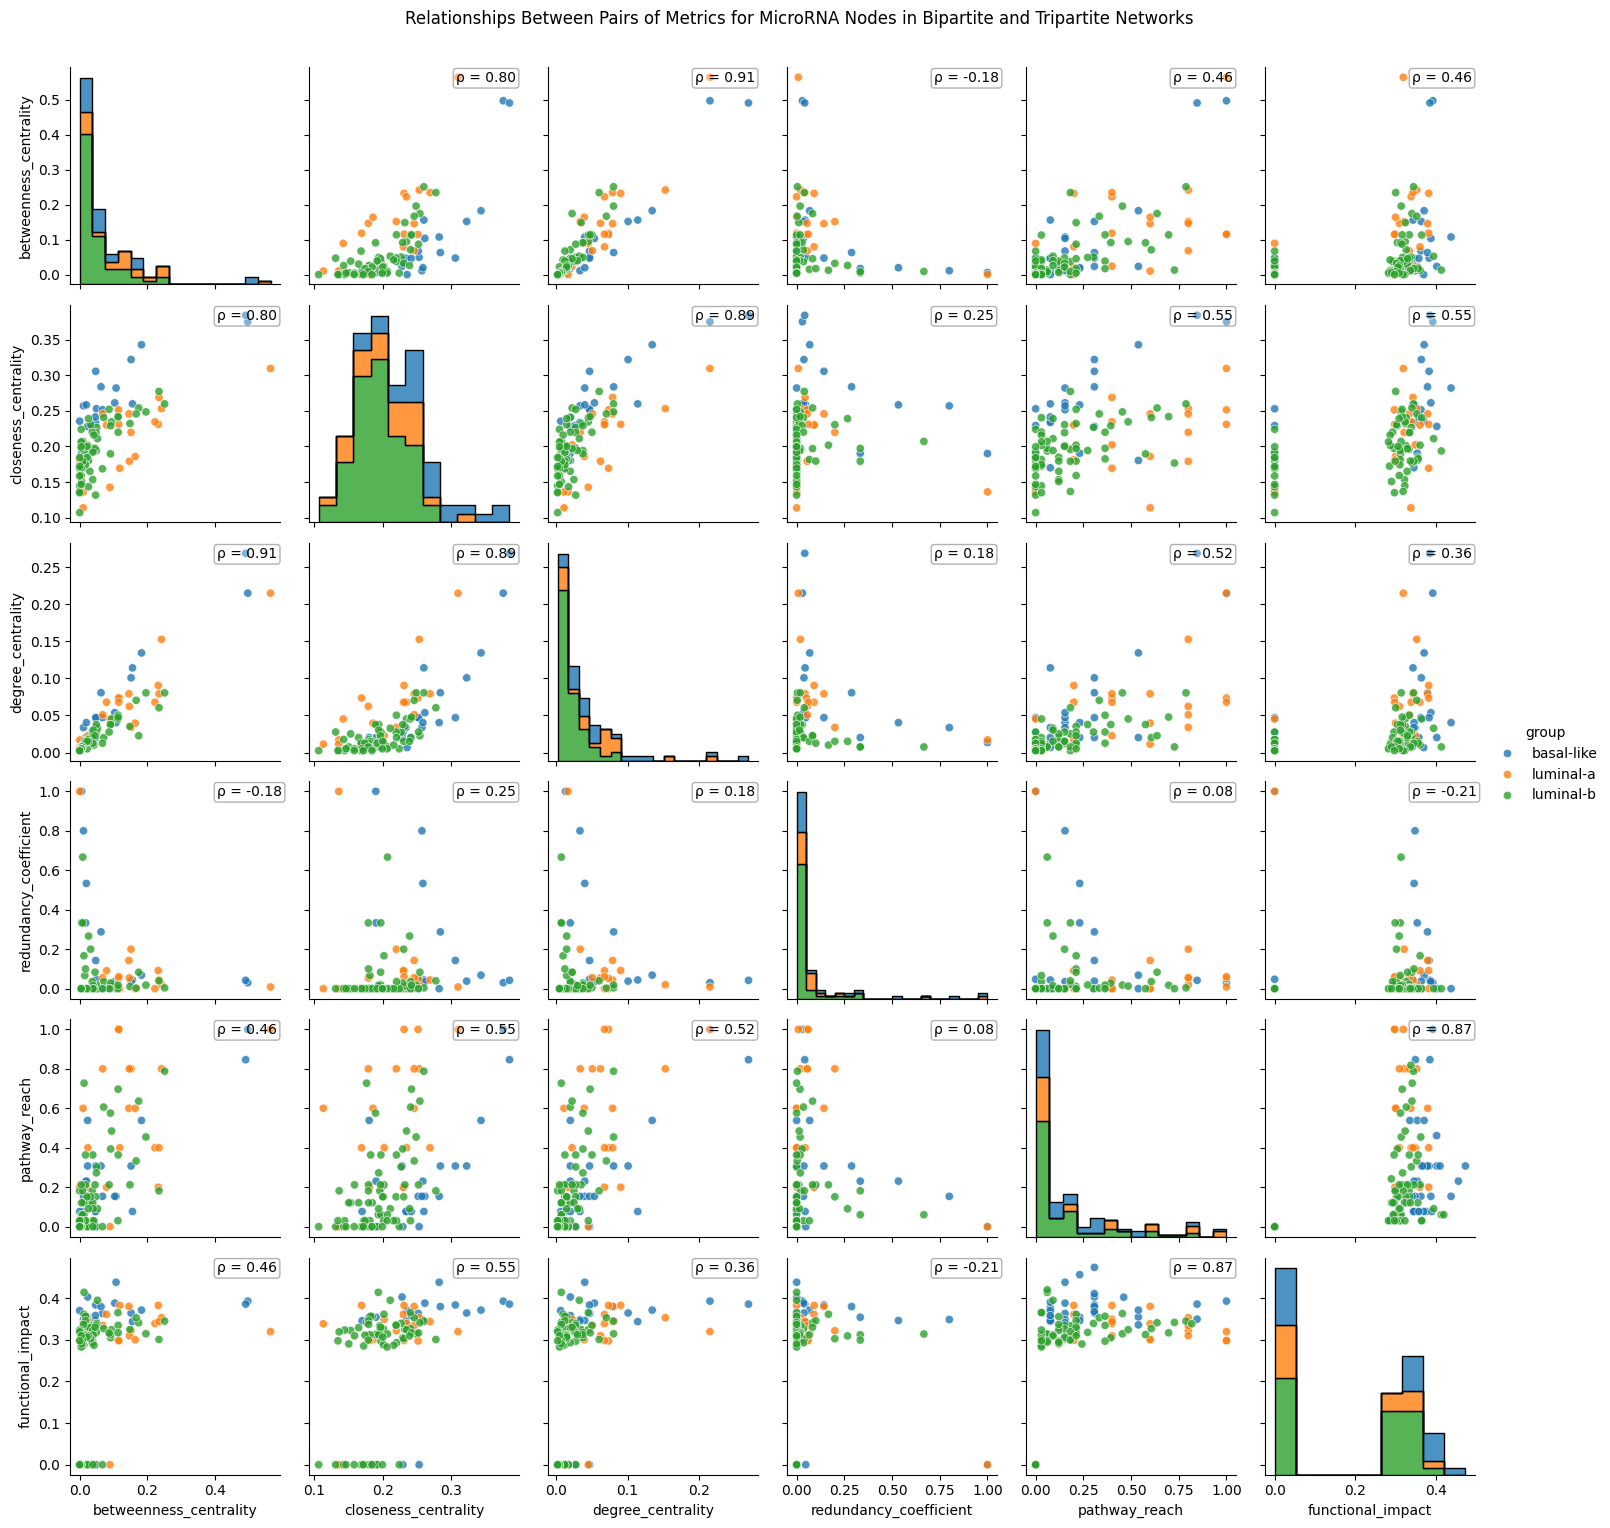

In [20]:
# Plot the grid of pairwise metric relationships
plot_pairwise_grid(cancer_networks['nodes'])

# Cancer vs Normal

## Data Preparation

In [21]:
# Create a dictionary to store abstracted data about cancer
abstracted_networks = dict()
abstracted_networks['edges'] = pd.DataFrame()
abstracted_networks['nodes'] = pd.DataFrame()

# Iterate over the network elements
for element in ['edges', 'nodes']:
    # Rename the group column
    df_elements = analyzed_networks[element] \
        .rename(columns={'group': 'detailed_group'})
    
    # Abstract the molecular subtype from cancer groups
    df_elements['group'] = np.where(
        df_elements['detailed_group'] != 'normal', 
        'cancer', 'normal'
    )

    # Store the abstracted DataFrame in the dictionary
    abstracted_networks[element] = df_elements.copy()

## MicroRNA-Gene-Pathway Path Sets

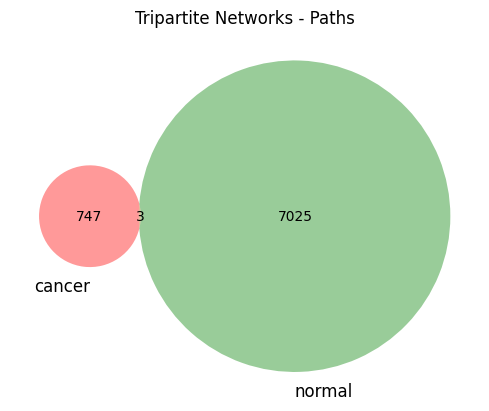

In [22]:
# Plot the Venn diagram of microRNA-gene-pathway paths
path_sets = plot_venn_diagram(
    df_nodes=abstracted_networks['nodes'], 
    element_name='paths'
)

### Intersections

In [23]:
# Print the microRNA-gene-pathway paths 
# resulting from the intersection between groups
print_intersection_elements(path_sets)

===== Tripartite Networks =====

##### 2-Set Intersections #####

> cancer ∩ normal = 3
['hsa-miR-200b-3p', 'FLI1', 'KEGG:05202']
['hsa-miR-200b-3p', 'ZEB1', 'KEGG:05202']
['hsa-miR-200c-3p', 'ZEB1', 'KEGG:05202']


### Differences

In [24]:
# Print the microRNA-gene-pathway paths 
# resulting from the difference between groups
print_different_elements(path_sets)

===== Tripartite Networks =====

##### 2-Set Differences #####

> cancer - normal = 747
['hsa-let-7b-5p', 'SENP5', 'KEGG:04068']
['hsa-let-7c-5p', 'IGF1R', 'KEGG:05202']
['hsa-let-7d-5p', 'PDE12', 'KEGG:05161']
['hsa-let-7e-5p', 'CD200R1', 'KEGG:01521']
['hsa-let-7e-5p', 'CD200R1', 'KEGG:01522']
['hsa-let-7e-5p', 'CD200R1', 'KEGG:04010']
['hsa-let-7e-5p', 'CD200R1', 'KEGG:04014']
['hsa-let-7e-5p', 'CD200R1', 'KEGG:04068']
['hsa-let-7e-5p', 'CD200R1', 'KEGG:04115']
['hsa-let-7e-5p', 'CD200R1', 'KEGG:04211']
['hsa-let-7e-5p', 'CD200R1', 'KEGG:05200']
['hsa-let-7e-5p', 'CD200R1', 'KEGG:05202']
['hsa-let-7e-5p', 'CD200R1', 'KEGG:05205']
['hsa-let-7e-5p', 'CD200R1', 'KEGG:05214']
['hsa-let-7i-5p', 'MSI2', 'KEGG:04010']
['hsa-let-7i-5p', 'MSI2', 'KEGG:04713']
['hsa-let-7i-5p', 'MSI2', 'KEGG:04720']
['hsa-let-7i-5p', 'MSI2', 'KEGG:04725']
['hsa-miR-106a-5p', 'AFF1', 'KEGG:01521']
['hsa-miR-106a-5p', 'AFF1', 'KEGG:04010']
['hsa-miR-106a-5p', 'AFF1', 'KEGG:04014']
['hsa-miR-106a-5p', 'AFF1', 'K

## MicroRNA-Pathway Pair Sets

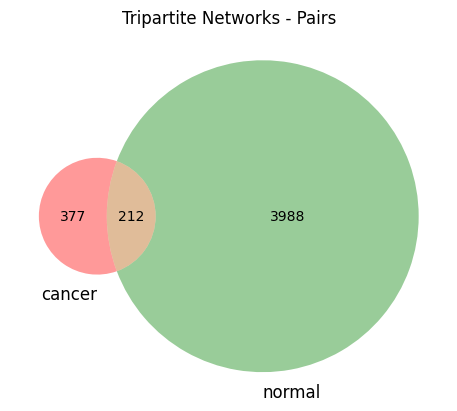

In [25]:
# Plot the Venn diagram of microRNA-pathway pairs
pair_sets = plot_venn_diagram(
    df_nodes=abstracted_networks['nodes'], 
    element_name='pairs'
    )

### Intersections

In [26]:
# Print the microRNA-pathway pairs 
# resulting from the intersection between groups
print_intersection_elements(pair_sets)

===== Tripartite Networks =====

##### 2-Set Intersections #####

> cancer ∩ normal = 212
['hsa-let-7b-5p', 'KEGG:04068']
['hsa-let-7c-5p', 'KEGG:05202']
['hsa-let-7d-5p', 'KEGG:05161']
['hsa-let-7e-5p', 'KEGG:04115']
['hsa-let-7e-5p', 'KEGG:05200']
['hsa-let-7e-5p', 'KEGG:05205']
['hsa-let-7i-5p', 'KEGG:04010']
['hsa-miR-106a-5p', 'KEGG:01521']
['hsa-miR-106a-5p', 'KEGG:04010']
['hsa-miR-106a-5p', 'KEGG:04014']
['hsa-miR-106a-5p', 'KEGG:04068']
['hsa-miR-106a-5p', 'KEGG:04151']
['hsa-miR-106a-5p', 'KEGG:04152']
['hsa-miR-106a-5p', 'KEGG:04380']
['hsa-miR-106a-5p', 'KEGG:04713']
['hsa-miR-106a-5p', 'KEGG:04725']
['hsa-miR-106a-5p', 'KEGG:04926']
['hsa-miR-106a-5p', 'KEGG:05161']
['hsa-miR-106a-5p', 'KEGG:05200']
['hsa-miR-106a-5p', 'KEGG:05202']
['hsa-miR-106a-5p', 'KEGG:05214']
['hsa-miR-106a-5p', 'KEGG:05215']
['hsa-miR-106a-5p', 'KEGG:05218']
['hsa-miR-106b-5p', 'KEGG:04010']
['hsa-miR-106b-5p', 'KEGG:04310']
['hsa-miR-106b-5p', 'KEGG:04520']
['hsa-miR-106b-5p', 'KEGG:05200']
['hsa-

### Differences

In [27]:
# Print the microRNA-pathway pairs 
# resulting from the difference between groups
print_different_elements(pair_sets)

===== Tripartite Networks =====

##### 2-Set Differences #####

> cancer - normal = 377
['hsa-let-7e-5p', 'KEGG:01521']
['hsa-let-7e-5p', 'KEGG:01522']
['hsa-let-7e-5p', 'KEGG:04010']
['hsa-let-7e-5p', 'KEGG:04014']
['hsa-let-7e-5p', 'KEGG:04068']
['hsa-let-7e-5p', 'KEGG:04211']
['hsa-let-7e-5p', 'KEGG:05202']
['hsa-let-7e-5p', 'KEGG:05214']
['hsa-let-7i-5p', 'KEGG:04713']
['hsa-let-7i-5p', 'KEGG:04720']
['hsa-let-7i-5p', 'KEGG:04725']
['hsa-miR-106a-5p', 'KEGG:04020']
['hsa-miR-106a-5p', 'KEGG:04115']
['hsa-miR-106b-5p', 'KEGG:01521']
['hsa-miR-106b-5p', 'KEGG:01522']
['hsa-miR-106b-5p', 'KEGG:04014']
['hsa-miR-106b-5p', 'KEGG:04020']
['hsa-miR-106b-5p', 'KEGG:04068']
['hsa-miR-106b-5p', 'KEGG:04115']
['hsa-miR-106b-5p', 'KEGG:04390']
['hsa-miR-106b-5p', 'KEGG:04659']
['hsa-miR-106b-5p', 'KEGG:04722']
['hsa-miR-106b-5p', 'KEGG:05165']
['hsa-miR-106b-5p', 'KEGG:05205']
['hsa-miR-125b-5p', 'KEGG:01521']
['hsa-miR-125b-5p', 'KEGG:04380']
['hsa-miR-125b-5p', 'KEGG:04550']
['hsa-miR-125b-5

## Node Classification

In [28]:
# Print the classification of the nodes according to the metric values
print_node_classification(abstracted_networks)

===== Tripartite Networks - MicroRNA Nodes =====

##### Pathway Reach - Descending Ranking #####

> specific = 36
- hsa-let-7b-5p: ['normal']
- hsa-let-7d-5p: ['normal']
- hsa-miR-107: ['normal']
- hsa-miR-139-5p: ['normal']
- hsa-miR-140-5p: ['normal']
- hsa-miR-145-5p: ['normal']
- hsa-miR-152-3p: ['normal']
- hsa-miR-15a-5p: ['normal']
- hsa-miR-181d-5p: ['normal']
- hsa-miR-192-5p: ['cancer']
- hsa-miR-196a-5p: ['cancer']
- hsa-miR-20a-5p: ['cancer']
- hsa-miR-20b-5p: ['normal']
- hsa-miR-22-3p: ['normal']
- hsa-miR-221-3p: ['cancer']
- hsa-miR-222-3p: ['cancer']
- hsa-miR-224-5p: ['normal']
- hsa-miR-27b-3p: ['cancer']
- hsa-miR-29c-3p: ['cancer']
- hsa-miR-30b-5p: ['cancer']
- hsa-miR-30e-5p: ['normal']
- hsa-miR-335-5p: ['cancer']
- hsa-miR-339-5p: ['normal']
- hsa-miR-33a-5p: ['cancer']
- hsa-miR-33b-5p: ['cancer']
- hsa-miR-342-3p: ['cancer']
- hsa-miR-34a-5p: ['cancer']
- hsa-miR-362-5p: ['normal']
- hsa-miR-421: ['normal']
- hsa-miR-429: ['cancer']
- hsa-miR-454-3p: ['normal

## Pairwise Metric Relationships

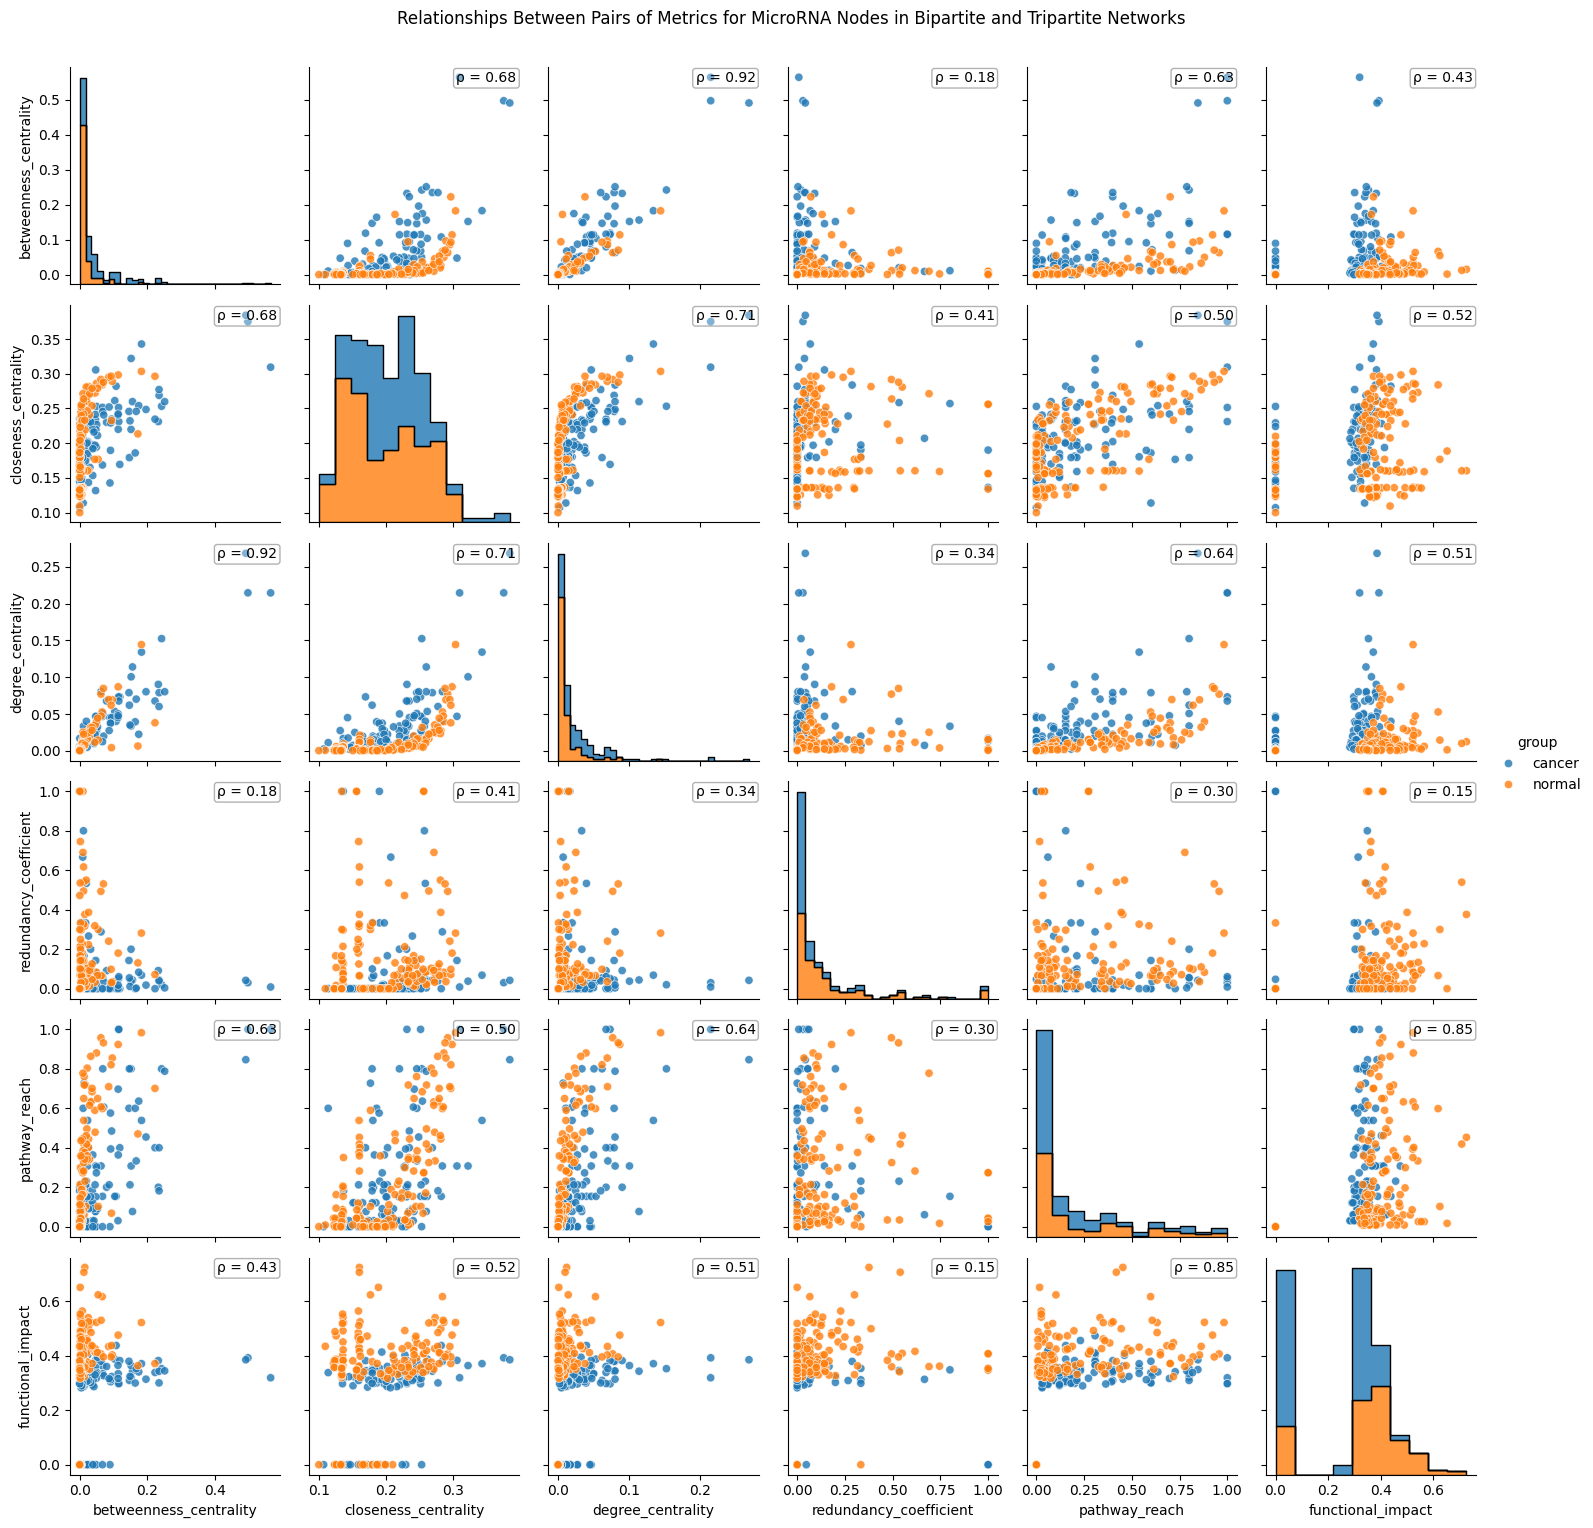

In [29]:
# Plot the grid of pairwise metric relationships
plot_pairwise_grid(abstracted_networks['nodes'])